<a href="https://colab.research.google.com/github/aburkov/theDRLbook/blob/main/gradient_ascent_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Ascent in NumPy

This notebook implements the gradient ascent algorithm to find the maximum of the objective function

$$J(\theta_1, \theta_2) = 10 - (\theta_1 - 2)^2 - (\theta_2 - 3)^2,$$

which has its global maximum at $[\theta_1, \theta_2] = [2, 3]$ with value $J = 10$.

The gradient is approximated numerically using the **central difference** method.

## Setup

`numpy` is preinstalled on Colab, so the import below is all we need.

In [7]:
import numpy as np

## The objective function

`theta` is a NumPy array of two values, unpacked into `theta1` and `theta2`. The function returns the value of $J$ at that point.

In [8]:
def objective_function(theta):
    theta1, theta2 = theta
    return 10 - (theta1 - 2)**2 - (theta2 - 3)**2

## Computing the gradient by finite differences

We approximate each partial derivative with the central difference formula

$$\frac{\partial J}{\partial \theta_i} \approx \frac{J(\ldots, \theta_i + h, \ldots) - J(\ldots, \theta_i - h, \ldots)}{2h},$$

where $h$ is a very small number. For each parameter we make independent copies of `theta` so that perturbing one component does not affect the others.

In [9]:
def compute_gradient(obj, theta, h=1e-5):
    grad = np.zeros_like(theta, dtype=float)

    for i in range(len(theta)):
        theta_plus_h = theta.copy()
        theta_plus_h[i] += h

        theta_minus_h = theta.copy()
        theta_minus_h[i] -= h

        grad[i] = (obj(theta_plus_h) - obj(theta_minus_h)) / (2 * h)

    return grad

## The gradient ascent loop

At each iteration we compute the gradient at the current `theta` and take a step of size `learning_rate` in its direction.

In [10]:
def gradient_ascent(theta, learning_rate, num_iterations, obj):
    for _ in range(num_iterations):
        grad = compute_gradient(obj, theta)
        theta += learning_rate * grad

    return theta

## Run it

We start from $[3.8, 1.5]$, use a learning rate of $0.1$, and run for 30 iterations. The result should be very close to the true maximum at $[2, 3]$.

In [11]:
theta_start = np.array([3.8, 1.5])
learning_rate = 0.1
max_iterations = 30

theta_optimal = gradient_ascent(
    theta_start,
    learning_rate,
    max_iterations,
    objective_function
)

print(f"Optimal theta: {theta_optimal}")
print(f"Objective function value at optimal theta: {objective_function(theta_optimal)}")

Optimal theta: [2.00222829 2.99814309]
Objective function value at optimal theta: 9.999991586599467


Expected output:

```
Optimal theta: [2.00222829 2.99814309]
Objective function value at optimal theta: 9.999991586599467
```

## Visualizing the ascent

To build intuition we plot the optimization on the objective surface. The left panel shows the 3D surface with the ascent path climbing toward the maximum; the right panel shows the same path on a contour map, together with gradient arrows that always point uphill.

We reuse `objective_function` and `compute_gradient` from above. The ascent loop is repeated here in a variant that records the full history of `theta` and `J` so the path can be drawn.

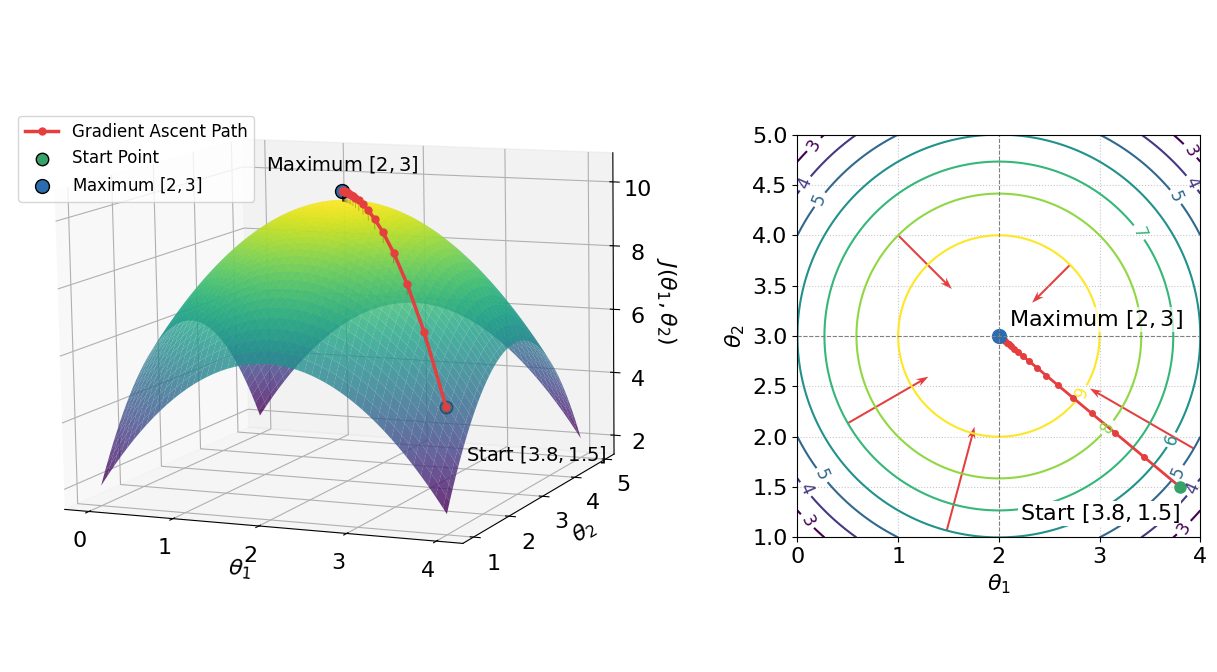

Optimal theta: [2.00222829 2.99814309]
Objective function value at optimal theta: 9.999991586599467


In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)
import matplotlib.gridspec as gridspec


def gradient_ascent_with_history(initial_theta, learning_rate, n_iterations, obj):
    theta = np.array(initial_theta, dtype=float)
    theta_history = [theta.copy()]
    J_history = [obj(theta)]
    for _ in range(n_iterations):
        grad = compute_gradient(obj, theta)
        theta += learning_rate * grad
        theta_history.append(theta.copy())
        J_history.append(obj(theta))
    return np.array(theta_history), np.array(J_history)


colors = {'blue': '#2B6CB0', 'yellow': '#F6AD55', 'red': '#E53E3E', 'green': '#38A169'}
FONT_SIZE = 16
plt.rcParams['font.size'] = FONT_SIZE

initial_theta = np.array([3.8, 1.5])
learning_rate = 0.1
num_iterations = 30
theta_path, J_values_path = gradient_ascent_with_history(
    initial_theta, learning_rate, num_iterations, objective_function
)

theta1_vals = np.linspace(0, 4, 100)
theta2_vals = np.linspace(1, 5, 100)
T1, T2 = np.meshgrid(theta1_vals, theta2_vals)
J_vals_surface = objective_function((T1, T2))

fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.43, 0.63])

# Left plot - 3D surface
ax1 = fig.add_subplot(gs[0], projection='3d')
ax1.plot_surface(T1, T2, J_vals_surface, cmap='viridis', edgecolor='none', alpha=0.8)
z_offset = 0.3
path_color = colors['red']
elevated_J_values_path = J_values_path + z_offset
ax1.plot(theta_path[:, 0], theta_path[:, 1], elevated_J_values_path,
         color=path_color, marker='o', linewidth=2.5, markersize=5,
         label='Gradient Ascent Path', zorder=10)
for i in range(len(theta_path)):
    ax1.plot([theta_path[i, 0], theta_path[i, 0]],
             [theta_path[i, 1], theta_path[i, 1]],
             [J_values_path[i], elevated_J_values_path[i]],
             'k-', linewidth=0.5, alpha=0.3, zorder=5)
ax1.scatter(theta_path[0, 0], theta_path[0, 1], elevated_J_values_path[0],
            color=colors['green'], s=80, edgecolor='k',
            label='Start Point', zorder=15)
true_max_params = (2, 3)
true_max_z_on_surface = objective_function(true_max_params)
ax1.scatter(true_max_params[0], true_max_params[1], true_max_z_on_surface + z_offset,
            color=colors['blue'], s=100, edgecolor='k',
            label=rf'Maximum $[{true_max_params[0]}, {true_max_params[1]}]$', zorder=15)
ax1.text(initial_theta[0] + 1.0, initial_theta[1], elevated_J_values_path[0] - 1.5,
         rf'Start $[{initial_theta[0]}, {initial_theta[1]}]$',
         color='black', fontsize=FONT_SIZE - 2, ha='center', va='bottom')
ax1.text(true_max_params[0], true_max_params[1], true_max_z_on_surface + z_offset + 0.5,
         rf'Maximum $[{true_max_params[0]}, {true_max_params[1]}]$',
         color='black', fontsize=FONT_SIZE - 2, ha='center', va='bottom')
ax1.set_xlabel(r'$\theta_1$')
ax1.set_ylabel(r'$\theta_2$')
ax1.set_zlabel(r'$J(\theta_1, \theta_2)$')
ax1.view_init(elev=10, azim=-66, roll=1)
ax1.set_xticks(np.arange(0, 4.1, 1))
ax1.set_yticks(np.arange(1, 5.1, 1))
min_j_val_surface = np.min(J_vals_surface)
max_j_val_surface = np.max(J_vals_surface)
ax1.set_zticks(np.linspace(round(min_j_val_surface), round(max_j_val_surface), num=5).astype(int))
ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 0.85), fontsize=FONT_SIZE - 4)

# Right plot - Contour plot
ax2 = fig.add_subplot(gs[1])
contour_levels_to_draw = np.array([3, 4, 5, 6, 7, 8, 9])
cp = ax2.contour(T1, T2, J_vals_surface, levels=contour_levels_to_draw, cmap='viridis', linewidths=1.5)
ax2.clabel(cp, inline=True, fontsize=12)

contour_levels_for_arrows = np.array([9, 8, 7, 6, 5])
angles_for_arrows_deg = np.array([45, 135, 210, 255, 330])
angles_for_arrows_rad = np.deg2rad(angles_for_arrows_deg)

center_t1, center_t2 = 2.0, 3.0
arrow_points_t1 = []
arrow_points_t2 = []
for C_arrow, angle_rad in zip(contour_levels_for_arrows, angles_for_arrows_rad):
    if 10 - C_arrow < 0:
        continue
    R_arrow = np.sqrt(10 - C_arrow)
    pt1 = center_t1 + R_arrow * np.cos(angle_rad)
    pt2 = center_t2 + R_arrow * np.sin(angle_rad)
    arrow_points_t1.append(pt1)
    arrow_points_t2.append(pt2)

for t1_pt, t2_pt in zip(arrow_points_t1, arrow_points_t2):
    current_theta_pt = np.array([t1_pt, t2_pt])
    grad = compute_gradient(objective_function, current_theta_pt)
    ax2.quiver(t1_pt, t2_pt, grad[0], grad[1], color=colors['red'],
               scale=15, width=0.005, angles='xy', headwidth=4, headlength=6)

ax2.plot(theta_path[:, 0], theta_path[:, 1], 'o-', color=path_color, markersize=4, linewidth=2)
ax2.plot(initial_theta[0], initial_theta[1], 'o', color=colors['green'], markersize=8)
ax2.plot(true_max_params[0], true_max_params[1], 'o', color=colors['blue'], markersize=10)
ax2.axvline(true_max_params[0], color='gray', linestyle='--', lw=0.8)
ax2.axhline(true_max_params[1], color='gray', linestyle='--', lw=0.8)
ax2.text(true_max_params[0] + 0.1, true_max_params[1] + 0.1,
         rf'Maximum $[{true_max_params[0]}, {true_max_params[1]}]$', color='black',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))
ax2.text(initial_theta[0], initial_theta[1] - 0.15,
         rf'Start $[{initial_theta[0]}, {initial_theta[1]}]$',
         color='black', ha='right', va='top',
         bbox=dict(facecolor='white', edgecolor='none', alpha=1.0, pad=1))
ax2.set_xlabel(r'$\theta_1$')
ax2.set_ylabel(r'$\theta_2$')
ax2.set_xlim(0, 4)
ax2.set_ylim(1, 5)
ax2.set_aspect(1.0)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Match the printed output of the "Run it" cell above exactly
theta_optimal = theta_path[-1]
print(f"Optimal theta: {theta_optimal}")
print(f"Objective function value at optimal theta: {objective_function(theta_optimal)}")